# **Load Dataset**

In [ ]:
# Import Required Libraries
import pandas as pd
import numpy as np

# Load Dataset
df=pd.read_csv('/content/Hospitality_Wrangling_EDA_Regression.csv')


# Set options to display all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# If you want to reset the options later to default behavior
# pd.reset_option('display.max_rows')
# pd.reset_option('display.max_columns')
df.head()


,Booking_ID,Hotel_ID,Country,Brand_Tier,Star_Rating,Room_Type,Nights_Stayed,Booking_Channel,Meals_Included,Payment_Type,Customer_Age,Lead_Time_Days,Checkin_Date,Checkin_Month,Is_Weekend,Is_Public_Holiday,Occupancy_Rate_Property,Competitor_Avg_Rate_RM,Distance_To_Center_KM,Review_Score,Promo_Applied,Events_Index_City,ADR_RM,Total_Spend_RM,Extra_Spend_Unscaled,Satisfaction_Rating
0,2360,H026,SINGAPORE,upscale,4,Double,4,Walk-in,No,Online,22.0,45,2024-05-13,5,0,0,0.784,415.14,0.83,7.95,0,70.9,458.75,1875.99,43173,2
1,2493,H006,Singapore,economy,1,Double,4,Walk-in,No,Online,22.0,41,2023-12-11,12,0,0,0.771,104.87,2.95,7.52,0,56.3,103.12,433.34,44423,4
2,172,H033,Thailand,midscale,4,suite,2,Online,Yes,Card,41.0,26,2024-06-12,6,0,0,0.715,514.49,0.98,8.73,1,56.2,525.62,1123.38,5022,4
3,5659,H018,Malaysia,midscale,3,Single,2,Travel Agent,Yes,Online,19.0,44,2023-12-20,12,0,1,0.780,265.64,3.68,7.71,0,75.0,263.75,635.46,104455,5
4,5719,H071,Thailand,Midscale,3,Double,2,Online,Yes,Card,35.0,65,2023-10-02,10,0,0,0.868,212.21,6.81,9.36,0,46.1,234.31,530.34,70545,5


# **Summary Statistics of Key Variables**

In [ ]:
df.describe()

,Booking_ID,Star_Rating,Nights_Stayed,Customer_Age,Lead_Time_Days,Checkin_Month,Is_Weekend,Is_Public_Holiday,Occupancy_Rate_Property,Competitor_Avg_Rate_RM,Distance_To_Center_KM,Review_Score,Promo_Applied,Events_Index_City,ADR_RM,Total_Spend_RM,Extra_Spend_Unscaled,Satisfaction_Rating
count,6630.000000,6630.000000,6630.000000,6368.000000,6630.000000,6630.000000,6630.000000,6630.000000,6562.000000,6447.000000,6630.000000,6489.000000,6630.000000,6490.000000,6599.000000,6630.000000,6630.000000,6630.000000
mean,3250.912217,2.936501,2.496682,37.610867,26.855505,6.244344,0.291855,0.102564,0.729266,288.429727,4.323927,8.306149,0.124133,54.874530,294.417935,803.040131,59830.687179,4.041780
std,1877.481753,1.147861,1.192159,11.641453,19.518938,3.413040,0.454650,0.303412,0.106688,193.514012,4.198526,1.074573,0.329758,11.155025,200.268278,652.926626,34996.892462,0.845549
min,1.000000,1.000000,1.000000,18.000000,0.000000,1.000000,0.000000,0.000000,0.347000,70.000000,0.650000,4.500000,0.000000,15.500000,35.000000,85.660000,136.000000,1.000000
25%,1621.250000,2.000000,2.000000,29.000000,11.000000,3.000000,0.000000,0.000000,0.656000,128.960000,2.800000,7.550000,0.000000,47.300000,131.820000,351.690000,29499.750000,4.000000
50%,3249.500000,3.000000,2.000000,37.000000,25.000000,6.000000,0.000000,0.000000,0.729000,242.820000,3.850000,8.400000,0.000000,54.700000,245.280000,597.150000,59329.500000,4.000000
75%,4876.750000,4.000000,3.000000,46.000000,40.000000,9.000000,1.000000,0.000000,0.803750,391.260000,5.550000,9.180000,0.000000,62.400000,397.945000,1040.710000,90485.000000,5.000000
max,6500.000000,5.000000,7.000000,75.000000,109.000000,12.000000,1.000000,1.000000,0.980000,1884.820000,58.870977,9.800000,1.000000,96.200000,1381.420000,5644.460000,119999.000000,5.000000


In [ ]:
# Summary statistics (mean, median, std) for numeric columns

numeric_cols = df.select_dtypes(include=['number']).columns.tolist()

summary = df[numeric_cols].describe().T  # contains mean, std, min, 25%, 50%, 75%, max
summary['median'] = df[numeric_cols].median()
summary = summary[['mean', 'median', 'std', 'min', '25%', '50%', '75%', 'max', 'count']]
summary = summary.rename(columns={'count':'n_nonnull'})
summary.style.format("{:.3f}")

,mean,median,std,min,25%,50%,75%,max,n_nonnull
Booking_ID,3250.912,3249.500,1877.482,1.000,1621.250,3249.500,4876.750,6500.000,6630.000
Star_Rating,2.937,3.000,1.148,1.000,2.000,3.000,4.000,5.000,6630.000
Nights_Stayed,2.497,2.000,1.192,1.000,2.000,2.000,3.000,7.000,6630.000
Customer_Age,37.611,37.000,11.641,18.000,29.000,37.000,46.000,75.000,6368.000
Lead_Time_Days,26.856,25.000,19.519,0.000,11.000,25.000,40.000,109.000,6630.000
Checkin_Month,6.244,6.000,3.413,1.000,3.000,6.000,9.000,12.000,6630.000
Is_Weekend,0.292,0.000,0.455,0.000,0.000,0.000,1.000,1.000,6630.000
Is_Public_Holiday,0.103,0.000,0.303,0.000,0.000,0.000,0.000,1.000,6630.000
Occupancy_Rate_Property,0.729,0.729,0.107,0.347,0.656,0.729,0.804,0.980,6562.000
Competitor_Avg_Rate_RM,288.430,242.820,193.514,70.000,128.960,242.820,391.260,1884.820,6447.000


In [ ]:
numeric_col=df.select_dtypes(include=('number'))

numeric_col.corr()

,Booking_ID,Star_Rating,Nights_Stayed,Customer_Age,Lead_Time_Days,Checkin_Month,Is_Weekend,Is_Public_Holiday,Occupancy_Rate_Property,Competitor_Avg_Rate_RM,Distance_To_Center_KM,Review_Score,Promo_Applied,Events_Index_City,ADR_RM,Total_Spend_RM,Extra_Spend_Unscaled,Satisfaction_Rating
Booking_ID,1.000000,-0.012066,0.011711,-0.011453,0.000337,0.021108,0.009457,0.012930,-0.005840,0.000411,-0.012722,-0.004884,0.012552,0.004767,-0.006618,-0.005536,0.017713,0.001370
Star_Rating,-0.012066,1.000000,-0.010351,-0.000321,-0.047197,-0.014637,-0.003217,-0.002088,-0.016358,0.855323,0.021416,0.792478,-0.006672,0.008779,0.849543,0.643544,0.000862,-0.018870
Nights_Stayed,0.011711,-0.010351,1.000000,-0.016945,0.004751,0.015585,-0.019783,0.007197,-0.019539,-0.009834,0.020636,-0.005521,0.013903,0.011473,-0.013347,0.539030,-0.005046,-0.002182
Customer_Age,-0.011453,-0.000321,-0.016945,1.000000,0.004318,0.016735,0.011553,-0.022586,-0.005875,-0.002245,0.000453,-0.006862,0.008956,-0.026227,0.001844,-0.021269,0.021543,0.004701
Lead_Time_Days,0.000337,-0.047197,0.004751,0.004318,1.000000,-0.010040,0.031832,-0.000834,-0.002015,-0.046348,-0.012147,-0.033487,-0.014369,0.021130,-0.042725,-0.032834,0.002646,-0.002020
Checkin_Month,0.021108,-0.014637,0.015585,0.016735,-0.010040,1.000000,0.005269,0.036687,0.030947,0.035032,0.006887,-0.018139,-0.001889,0.118547,0.022535,0.018701,-0.005930,0.020089
Is_Weekend,0.009457,-0.003217,-0.019783,0.011553,0.031832,0.005269,1.000000,0.034489,0.231081,0.072393,0.001794,0.011201,-0.029378,0.007587,0.080477,0.053880,0.001815,0.001238
Is_Public_Holiday,0.012930,-0.002088,0.007197,-0.022586,-0.000834,0.036687,0.034489,1.000000,0.120082,0.040842,0.005415,-0.001339,-0.023235,0.029069,0.039874,0.037073,-0.002250,0.012695
Occupancy_Rate_Property,-0.005840,-0.016358,-0.019539,-0.005875,-0.002015,0.030947,0.231081,0.120082,1.000000,0.018854,0.008930,-0.015290,-0.158795,0.216075,0.054460,0.039496,-0.008902,-0.000304
Competitor_Avg_Rate_RM,0.000411,0.855323,-0.009834,-0.002245,-0.046348,0.035032,0.072393,0.040842,0.018854,1.000000,0.034424,0.669592,-0.008659,0.072200,0.952233,0.727130,0.002072,-0.021030


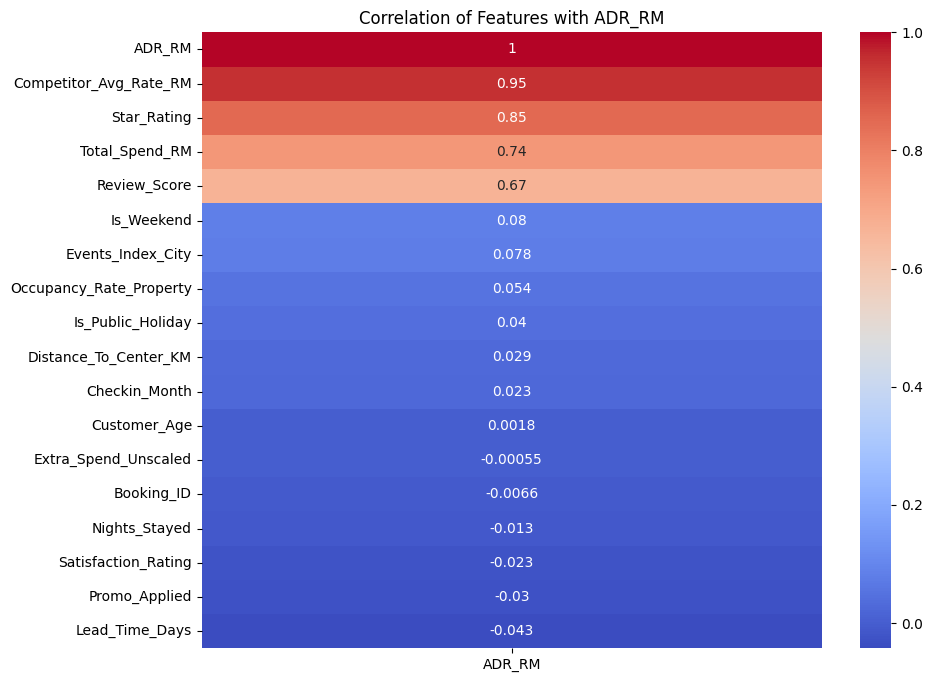

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr[['ADR_RM']].sort_values(by='ADR_RM', ascending=False), annot=True, cmap='coolwarm')
plt.title('Correlation of Features with ADR_RM')
plt.show()

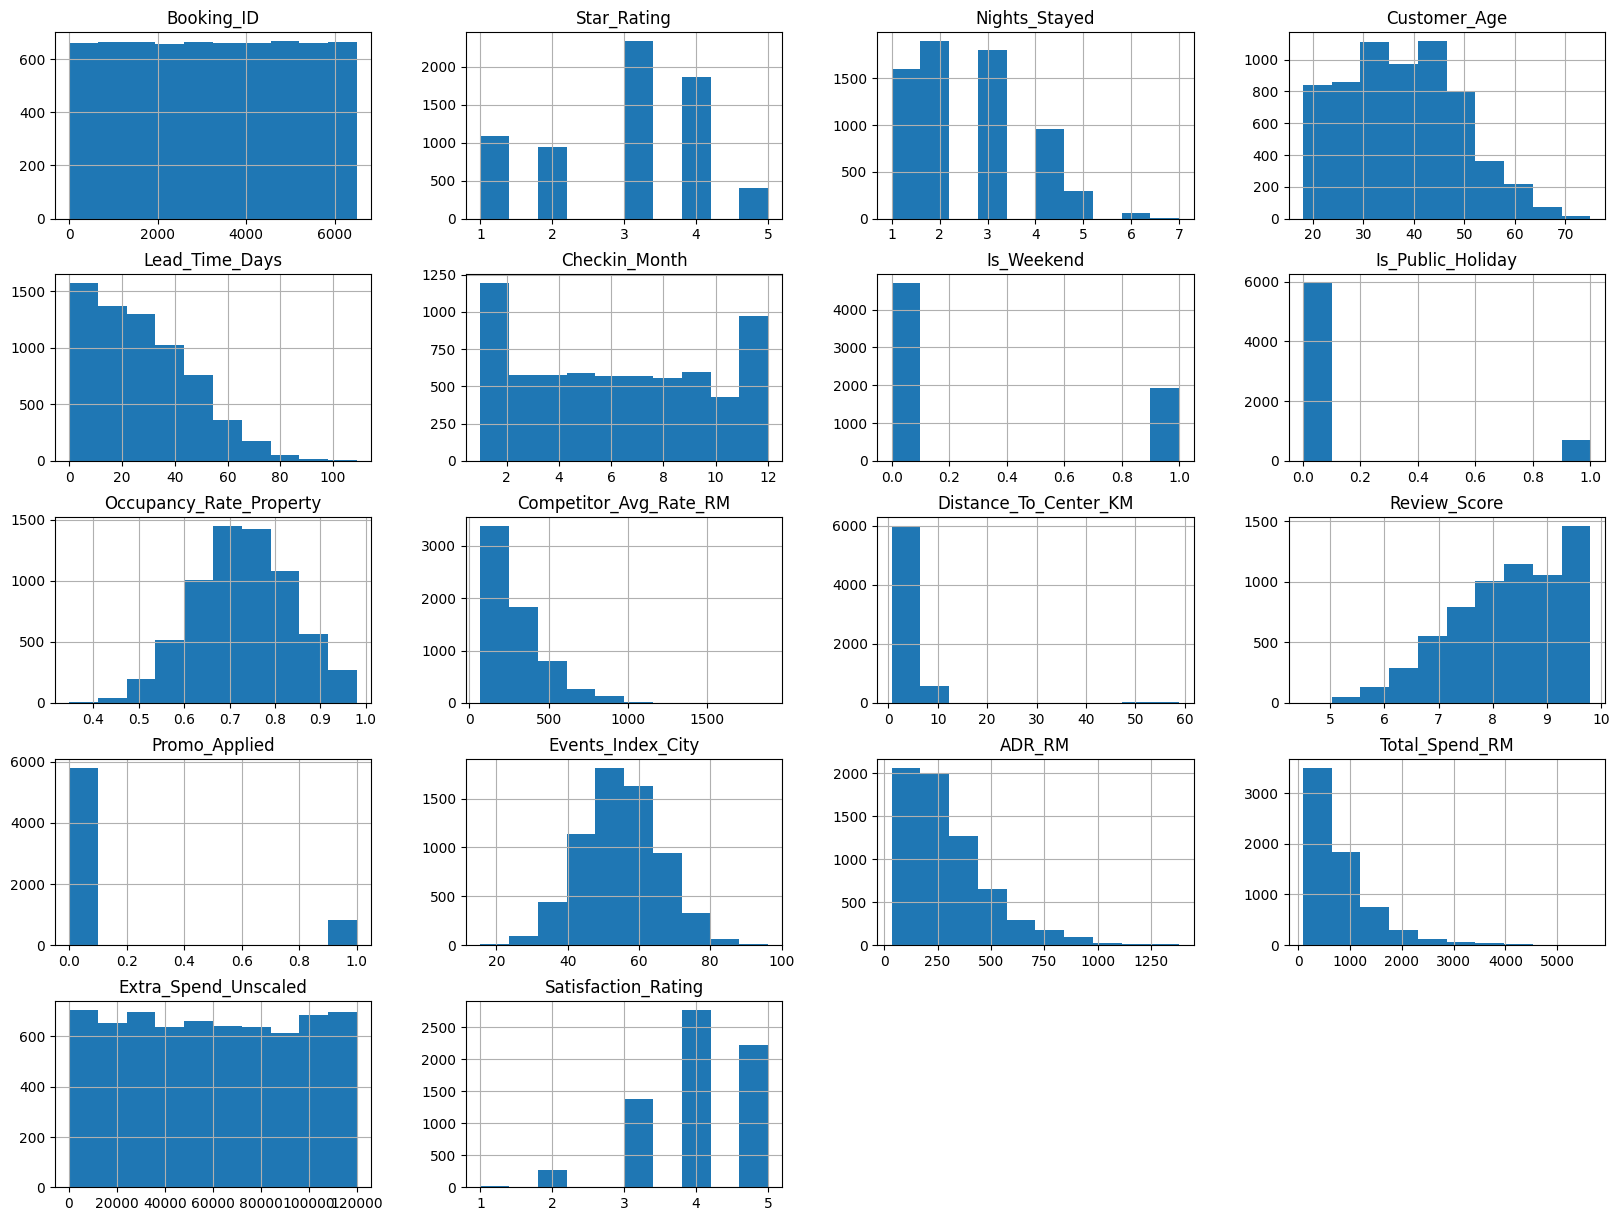

In [ ]:
numeric_col.hist(figsize=(20,15))

plt.show()

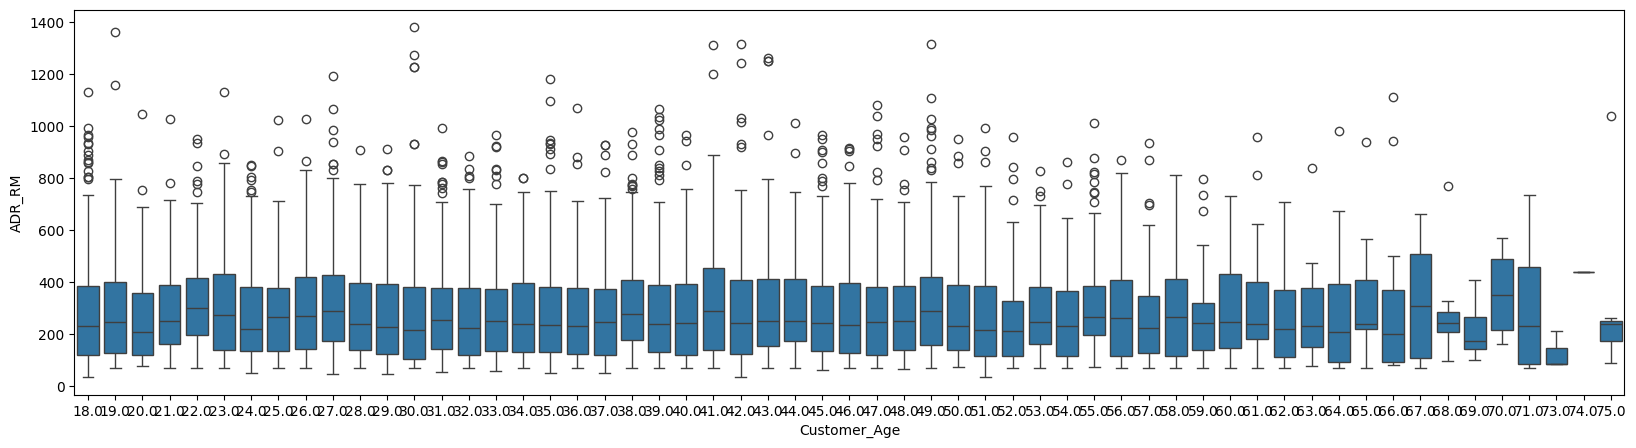

In [ ]:
plt.figure(figsize=(20,5))
sns.boxplot(x='Customer_Age', y='ADR_RM', data=df)

plt.show()

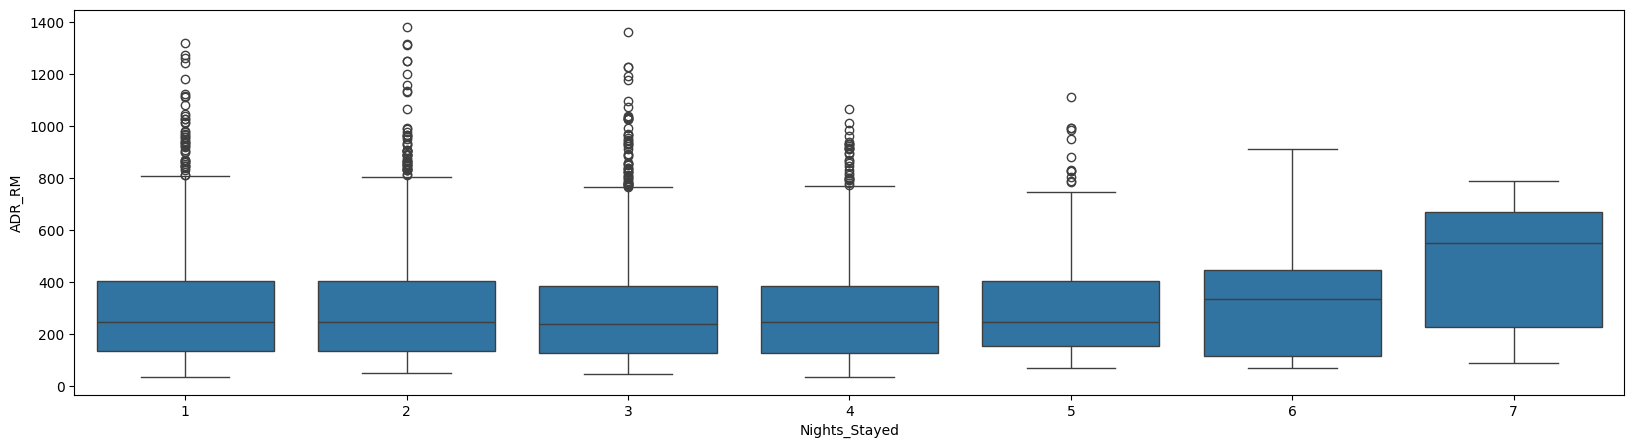

In [ ]:
plt.figure(figsize=(20,5))
sns.boxplot(x='Nights_Stayed', y='ADR_RM', data=df)

plt.show()

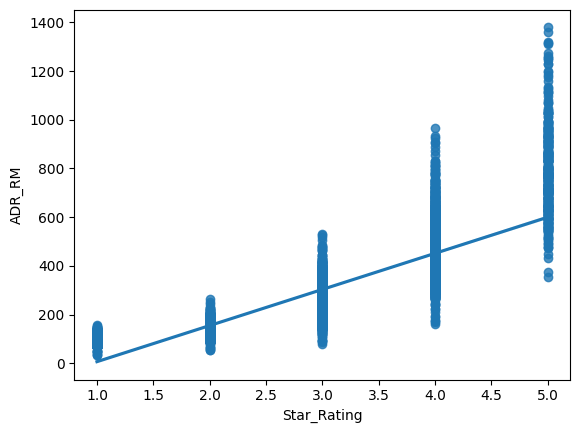

In [ ]:
sns.regplot(x='Star_Rating', y='ADR_RM', data=df)

plt.show()

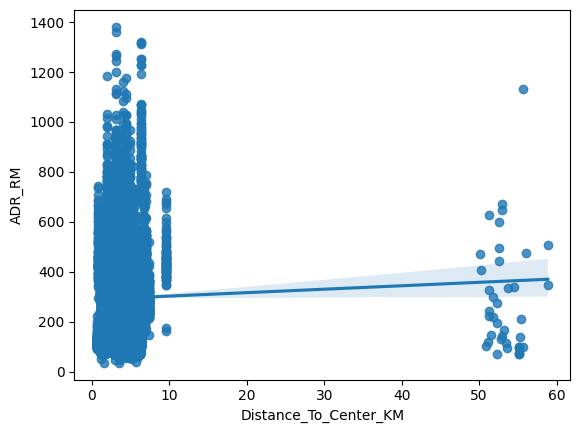

In [ ]:
sns.regplot(x='Distance_To_Center_KM', y='ADR_RM', data=df)

plt.show()

In [ ]:

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

print(f"Numerical columns found: {list(numeric_cols)}")
skewness = df[numeric_cols].skew().sort_values(ascending=False)
print("\n--- Skewness of Numerical Features ---")
print(skewness)

Numerical columns found: ['Booking_ID', 'Star_Rating', 'Nights_Stayed', 'Customer_Age', 'Lead_Time_Days', 'Checkin_Month', 'Is_Weekend', 'Is_Public_Holiday', 'Occupancy_Rate_Property', 'Competitor_Avg_Rate_RM', 'Distance_To_Center_KM', 'Review_Score', 'Promo_Applied', 'Events_Index_City', 'ADR_RM', 'Total_Spend_RM', 'Extra_Spend_Unscaled', 'Satisfaction_Rating']

--- Skewness of Numerical Features ---
Distance_To_Center_KM      9.451565
Is_Public_Holiday          2.620571
Promo_Applied              2.280345
Total_Spend_RM             2.110608
Competitor_Avg_Rate_RM     1.419798
ADR_RM                     1.375235
Is_Weekend                 0.915902
Lead_Time_Days             0.560787
Nights_Stayed              0.511761
Customer_Age               0.208754
Checkin_Month              0.075257
Events_Index_City          0.057788
Extra_Spend_Unscaled       0.015943
Booking_ID                -0.000132
Occupancy_Rate_Property   -0.067141
Star_Rating               -0.278712
Review_Score       

# **Data Wrangling**

In [ ]:
# Basic Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6630 entries, 0 to 6629
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Booking_ID               6630 non-null   int64  
 1   Hotel_ID                 6630 non-null   object 
 2   Country                  6529 non-null   object 
 3   Brand_Tier               6630 non-null   object 
 4   Star_Rating              6630 non-null   int64  
 5   Room_Type                6630 non-null   object 
 6   Nights_Stayed            6630 non-null   int64  
 7   Booking_Channel          6630 non-null   object 
 8   Meals_Included           6472 non-null   object 
 9   Payment_Type             6630 non-null   object 
 10  Customer_Age             6368 non-null   float64
 11  Lead_Time_Days           6630 non-null   int64  
 12  Checkin_Date             6630 non-null   object 
 13  Checkin_Month            6630 non-null   int64  
 14  Is_Weekend              

In [ ]:
# Checking for Duplicates
df.duplicated().sum()

np.int64(19)

In [ ]:
# Removing Duplicates
df_clean=df.drop_duplicates().reset_index(drop=True)

df_clean.shape

(6611, 26)

In [ ]:
# Checking for Duplicates After Cleaning
df_clean.duplicated().sum()

np.int64(0)

In [ ]:
# Checking Missing Values
df_clean.isnull().sum()

,0
Booking_ID,0
Hotel_ID,0
Country,101
Brand_Tier,0
Star_Rating,0
Room_Type,0
Nights_Stayed,0
Booking_Channel,0
Meals_Included,158
Payment_Type,0


In [ ]:
# Adjusting Missing Values

df_clean['Country'].replace(np.nan, df_clean['Country'].mode()[0], inplace=True)
df_clean['Meals_Included'].replace(np.nan, df_clean['Meals_Included'].mode()[0], inplace=True)
df_clean['Customer_Age'].replace(np.nan, df_clean['Customer_Age'].mean(), inplace=True)
df_clean['Occupancy_Rate_Property'].replace(np.nan, df_clean['Occupancy_Rate_Property'].mean(), inplace=True)
df_clean['Competitor_Avg_Rate_RM'].replace(np.nan, df_clean['Competitor_Avg_Rate_RM'].mean(), inplace=True)
df_clean['Review_Score'].replace(np.nan, df_clean['Review_Score'].mean(), inplace=True)
df_clean['Events_Index_City'].replace(np.nan, df_clean['Events_Index_City'].mean(), inplace=True)
df_clean['ADR_RM'].replace(np.nan, df_clean['ADR_RM'].mean(), inplace=True)
df_clean.isnull().sum()

/tmp/ipython-input-2454538472.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['Country'].replace(np.nan, df_clean['Country'].mode()[0], inplace=True)
/tmp/ipython-input-2454538472.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].meth

,0
Booking_ID,0
Hotel_ID,0
Country,0
Brand_Tier,0
Star_Rating,0
Room_Type,0
Nights_Stayed,0
Booking_Channel,0
Meals_Included,0
Payment_Type,0


In [ ]:
# Identify outliers using IQR
numeric_cols=df_clean.select_dtypes(include=['number']).columns.tolist()

print("\nIdentifying outliers using IQR:")
outlier_indices = {}
for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)].index
    outlier_indices[col] = outliers
    print(f"  {col:>20}: {len(outliers)} outliers identified")

# Combine indices from all columns
all_outlier_indices = [idx for indices in outlier_indices.values() for idx in indices]
all_outlier_indices = list(set(all_outlier_indices)) # Remove duplicates

print(f"\nTotal unique outliers identified across numeric columns: {len(all_outlier_indices)}")


Identifying outliers using IQR:
            Booking_ID: 0 outliers identified
           Star_Rating: 0 outliers identified
         Nights_Stayed: 364 outliers identified
          Customer_Age: 19 outliers identified
        Lead_Time_Days: 26 outliers identified
         Checkin_Month: 0 outliers identified
            Is_Weekend: 0 outliers identified
     Is_Public_Holiday: 676 outliers identified
  Occupancy_Rate_Property: 21 outliers identified
  Competitor_Avg_Rate_RM: 181 outliers identified
  Distance_To_Center_KM: 39 outliers identified
          Review_Score: 8 outliers identified
         Promo_Applied: 820 outliers identified
     Events_Index_City: 52 outliers identified
                ADR_RM: 185 outliers identified
        Total_Spend_RM: 343 outliers identified
  Extra_Spend_Unscaled: 0 outliers identified
   Satisfaction_Rating: 275 outliers identified

Total unique outliers identified across numeric columns: 2280


In [ ]:
# Cleaning the Outliers

df_clean=df_clean.drop(all_outlier_indices).reset_index(drop=True)

df_clean.shape

(4331, 26)

## **Feature Engineering**

In [ ]:
# Spend per Night
df_clean['Spend_Per_Night'] = df_clean['Total_Spend_RM'] / (df_clean['Nights_Stayed'] + 1)

# Event–Distance Interaction
df_clean['Event_Distance_Interaction'] = df_clean['Events_Index_City'] / (df_clean['Distance_To_Center_KM'] + 1)

# Occupancy Demand Pressure
df_clean['Demand_Pressure'] = df_clean['Occupancy_Rate_Property'] * df_clean['Events_Index_City']


# Price Competitiveness
df_clean['Price_Competitiveness'] = df_clean['ADR_RM'] / (df_clean['Competitor_Avg_Rate_RM'] + 1)

# Customer Value Index
df_clean['Customer_Value_Index'] = (df_clean['Total_Spend_RM']+ df_clean['Extra_Spend_Unscaled']) / (df_clean['Nights_Stayed'] + 1)

In [ ]:
new_features = ['Spend_Per_Night', 'Event_Distance_Interaction',
                'Demand_Pressure','Price_Competitiveness',
                'Customer_Value_Index']

df_clean[new_features].head()

,Spend_Per_Night,Event_Distance_Interaction,Demand_Pressure,Price_Competitiveness,Customer_Value_Index
0,86.668000,14.253165,43.4073,0.974025,8971.2680
1,176.780000,5.902689,40.0148,1.098963,23691.7800
2,87.802500,13.854167,40.2724,1.005989,13362.8025
3,95.066000,9.693431,53.7176,0.325336,18852.2660
4,168.093333,11.071429,36.9520,0.903356,7699.7600


**Categoric Features**




In [ ]:
categoric_features=df_clean.select_dtypes(include=['object'])

categoric_features.head()

,Hotel_ID,Country,Brand_Tier,Room_Type,Booking_Channel,Meals_Included,Payment_Type,Checkin_Date
0,H006,Singapore,economy,Double,Walk-in,No,Online,2023-12-11
1,H071,Thailand,Midscale,Double,Online,Yes,Card,2023-10-02
2,H005,UK,economy,Single,Online,Yes,Online,2022-12-10
3,H074,Malaysia,economy,Double,Travel Agent,Yes,Card,2024-12-06
4,H066,THAILAND,midscale,Single,Online,Yes,Card,2022-11-07


**Text hygiene for Categoric Features**

In [ ]:
cat_cols = ["Country","Brand_Tier","Room_Type",
            "Booking_Channel","Meals_Included",
            "Payment_Type"]

cat_cols = [c for c in cat_cols if c in df_clean.columns]


df_clean[cat_cols] = (
    df_clean[cat_cols]
      .apply(lambda s: s.where(s.isna(), s.astype(str).str.strip().str.lower()))
      .replace(['nan', 'none', '', 'na', 'n/a'], np.nan)
)

In [ ]:
categoric_features_clean=df_clean.select_dtypes(include=['object'])

categoric_features_clean.head()

,Hotel_ID,Country,Brand_Tier,Room_Type,Booking_Channel,Meals_Included,Payment_Type,Checkin_Date
0,H006,singapore,economy,double,walk-in,no,online,2023-12-11
1,H071,thailand,midscale,double,online,yes,card,2023-10-02
2,H005,uk,economy,single,online,yes,online,2022-12-10
3,H074,malaysia,economy,double,travel agent,yes,card,2024-12-06
4,H066,thailand,midscale,single,online,yes,card,2022-11-07


In [ ]:
# Rechecking for Missing Values

df_clean.isnull().sum()

,0
Booking_ID,0
Hotel_ID,0
Country,11
Brand_Tier,0
Star_Rating,0
Room_Type,0
Nights_Stayed,0
Booking_Channel,0
Meals_Included,13
Payment_Type,0


In [ ]:
# Emergency Cleaning to fill up the missing values

df_clean['Country'].replace(np.nan, df_clean['Country'].mode()[0], inplace=True)
df_clean['Meals_Included'].replace(np.nan, df_clean['Meals_Included'].mode()[0], inplace=True)

/tmp/ipython-input-1640120527.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['Country'].replace(np.nan, df_clean['Country'].mode()[0], inplace=True)
/tmp/ipython-input-1640120527.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].meth

In [ ]:
categoric_features_clean['Hotel_ID'].value_counts()


,count
Hotel_ID,
H073,73
H060,73
H053,70
H028,68
H008,67
H032,67
H034,67
H080,67
H020,65


In [ ]:
categoric_features_clean['Country'].value_counts()

,count
Country,
usa,725
singapore,626
philippines,533
thailand,460
uk,455
germany,337
malaysia,333
india,290
vietnam,289


In [ ]:
categoric_features_clean['Brand_Tier'].value_counts()

,count
Brand_Tier,
economy,1675
midscale,1524
upscale,1024
luxury,108


In [ ]:
categoric_features_clean['Room_Type'].value_counts()

,count
Room_Type,
single,2236
double,1640
suite,455


In [ ]:
categoric_features_clean['Booking_Channel'].value_counts()

,count
Booking_Channel,
online,2286
travel agent,856
walk-in,623
corporate,566


In [ ]:
categoric_features_clean['Meals_Included'].value_counts()

,count
Meals_Included,
yes,2851
no,1467


In [ ]:
categoric_features_clean['Payment_Type'].value_counts()

,count
Payment_Type,
card,2628
online,1190
cash,513


# **Encoding Techinques**

In [ ]:
# Label-encode each categorical column
from sklearn.preprocessing import LabelEncoder

encoders = {}

# Apply encoding directly to df_clean
for col in cat_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    encoders[col] = le

# preview
df_clean[cat_cols].head()

,Country,Brand_Tier,Room_Type,Booking_Channel,Meals_Included,Payment_Type
0,5,0,0,3,0,2
1,6,2,0,1,1,0
2,7,0,1,1,1,2
3,3,0,0,2,1,0
4,6,2,1,1,1,0


In [ ]:
numeric_features=df_clean.select_dtypes(include=('number'))

numeric_features.head()

,Booking_ID,Country,Brand_Tier,Star_Rating,Room_Type,Nights_Stayed,Booking_Channel,Meals_Included,Payment_Type,Customer_Age,Lead_Time_Days,Checkin_Month,Is_Weekend,Is_Public_Holiday,Occupancy_Rate_Property,Competitor_Avg_Rate_RM,Distance_To_Center_KM,Review_Score,Promo_Applied,Events_Index_City,ADR_RM,Total_Spend_RM,Extra_Spend_Unscaled,Satisfaction_Rating,Spend_Per_Night,Event_Distance_Interaction,Demand_Pressure,Price_Competitiveness,Customer_Value_Index
0,2493,5,0,1,0,4,3,0,2,22.0,41,12,0,0,0.771,104.870000,2.95,7.52,0,56.3,103.12,433.34,44423,4,86.668000,14.253165,43.4073,0.974025,8971.2680
1,5719,6,2,3,0,2,1,1,0,35.0,65,10,0,0,0.868,212.210000,6.81,9.36,0,46.1,234.31,530.34,70545,5,176.780000,5.902689,40.0148,1.098963,23691.7800
2,859,7,0,1,1,3,1,1,2,39.0,14,12,1,0,0.757,82.480000,2.84,7.36,0,53.2,83.98,351.21,53100,4,87.802500,13.854167,40.2724,1.005989,13362.8025
3,1866,3,0,1,0,4,2,1,0,34.0,21,12,0,0,0.809,288.485228,5.85,6.02,0,66.4,94.18,475.33,93786,4,95.066000,9.693431,53.7176,0.325336,18852.2660
4,6194,6,2,3,1,2,1,1,0,35.0,17,11,0,0,0.745,212.670000,3.48,8.32,0,49.6,193.02,504.28,22595,5,168.093333,11.071429,36.9520,0.903356,7699.7600


In [ ]:
# Saving the Clean New Dataset for EDA
numeric_features.to_csv('For_EDA_cleaned_encoded.csv', index=False)

In [ ]:
# Normalization

from sklearn.preprocessing import StandardScaler
import pandas as pd

SS_norm = StandardScaler()

# Keep ADR_RM separate as y
y = numeric_features["ADR_RM"].astype(float)

# Choose only the numeric columns EXCEPT ADR_RM to scale
cols_to_scale = [c for c in numeric_features.columns if c != "ADR_RM"]

# Fit/transform on those columns only
numeric_features_norm_array = SS_norm.fit_transform(numeric_features[cols_to_scale])

# Put back into a DataFrame with the same index/col names
numeric_features_norm = pd.DataFrame(
    numeric_features_norm_array,
    columns=cols_to_scale,
    index=numeric_features.index
)

# Reattach ADR_RM unscaled if you want a single table
numeric_features_norm["ADR_RM"] = y

numeric_features_norm.head()


,Booking_ID,Country,Brand_Tier,Star_Rating,Room_Type,Nights_Stayed,Booking_Channel,Meals_Included,Payment_Type,Customer_Age,Lead_Time_Days,Checkin_Month,Is_Weekend,Is_Public_Holiday,Occupancy_Rate_Property,Competitor_Avg_Rate_RM,Distance_To_Center_KM,Review_Score,Promo_Applied,Events_Index_City,Total_Spend_RM,Extra_Spend_Unscaled,Satisfaction_Rating,Spend_Per_Night,Event_Distance_Interaction,Demand_Pressure,Price_Competitiveness,Customer_Value_Index,ADR_RM
0,-0.395127,0.010891,-1.177065,-1.678259,-1.136013,1.696799,1.865455,-1.397241,1.516693,-1.385938,0.741407,1.714678,-0.644125,0.0,0.380958,-1.040489,-0.579580,-0.695655,0.0,0.129505,-0.543524,-0.435050,-0.181098,-1.072646,0.199734,0.286271,-0.285390,-0.800818,103.12
1,1.327549,0.385259,0.460015,0.148007,-1.136013,-0.300439,-0.402096,0.715696,-0.760581,-0.228929,2.000102,1.125619,-0.644125,0.0,1.327015,-0.313986,1.517069,1.073120,0.0,-0.837576,-0.314238,0.310361,1.171203,-0.205708,-1.056589,-0.038095,0.376154,0.245416,234.31
2,-1.267680,0.759627,-1.177065,-1.678259,0.427900,0.698180,-0.402096,0.715696,1.516693,0.127073,-0.674624,1.714678,1.552494,0.0,0.244414,-1.192030,-0.639329,-0.849462,0.0,-0.164412,-0.737660,-0.187445,-0.181098,-1.061732,0.139705,-0.013465,-0.116139,-0.488697,83.98
3,-0.729944,-0.737844,-1.177065,-1.678259,-1.136013,1.696799,0.731679,0.715696,-0.760581,-0.317930,-0.307505,1.714678,-0.644125,0.0,0.751578,0.202263,0.995622,-2.137591,0.0,1.087104,-0.444269,0.973560,-0.181098,-0.991852,-0.486275,1.272066,-3.720163,-0.098544,94.18
4,1.581198,0.385259,0.460015,0.148007,0.427900,-0.300439,-0.402096,0.715696,-0.760581,-0.228929,-0.517287,1.420148,-0.644125,0.0,0.127376,-0.310873,-0.291698,0.073377,0.0,-0.505735,-0.375838,-1.057928,1.171203,-0.289280,-0.278956,-0.330937,-0.659580,-0.891188,193.02


In [ ]:
# Saving the Clean, Encoded and Normalized New Dataset for Regression
numeric_features_norm.to_csv('For_Regression_cleaned_encoded_normalized.csv', index=False)

# **Exploratory Data Anlysis on Cleaned Encoded Dataset**

**Load New Cleaned Dataset for EDA (For_EDA_cleaned_encoded.csv)**

In [ ]:
eda_df=pd.read_csv('/content/For_EDA_cleaned_encoded.csv')
eda_df.head()

,Booking_ID,Country,Brand_Tier,Star_Rating,Room_Type,Nights_Stayed,Booking_Channel,Meals_Included,Payment_Type,Customer_Age,Lead_Time_Days,Checkin_Month,Is_Weekend,Is_Public_Holiday,Occupancy_Rate_Property,Competitor_Avg_Rate_RM,Distance_To_Center_KM,Review_Score,Promo_Applied,Events_Index_City,ADR_RM,Total_Spend_RM,Extra_Spend_Unscaled,Satisfaction_Rating,Spend_Per_Night,Event_Distance_Interaction,Demand_Pressure,Price_Competitiveness,Customer_Value_Index
0,2493,5,0,1,0,4,3,0,2,22.0,41,12,0,0,0.771,104.870000,2.95,7.52,0,56.3,103.12,433.34,44423,4,86.668000,14.253165,43.4073,0.974025,8971.2680
1,5719,6,2,3,0,2,1,1,0,35.0,65,10,0,0,0.868,212.210000,6.81,9.36,0,46.1,234.31,530.34,70545,5,176.780000,5.902689,40.0148,1.098963,23691.7800
2,859,7,0,1,1,3,1,1,2,39.0,14,12,1,0,0.757,82.480000,2.84,7.36,0,53.2,83.98,351.21,53100,4,87.802500,13.854167,40.2724,1.005989,13362.8025
3,1866,3,0,1,0,4,2,1,0,34.0,21,12,0,0,0.809,288.485228,5.85,6.02,0,66.4,94.18,475.33,93786,4,95.066000,9.693431,53.7176,0.325336,18852.2660
4,6194,6,2,3,1,2,1,1,0,35.0,17,11,0,0,0.745,212.670000,3.48,8.32,0,49.6,193.02,504.28,22595,5,168.093333,11.071429,36.9520,0.903356,7699.7600


In [ ]:
# Skewness Checking on Cleaned Dataset

numeric_cols = eda_df.select_dtypes(include=['int64', 'float64']).columns

print(f"Numerical columns found: {list(numeric_cols)}")
skewness = eda_df[numeric_cols].skew().sort_values(ascending=False)
print("\n--- Skewness of Numerical Features ---")
print(skewness)

Numerical columns found: ['Booking_ID', 'Country', 'Brand_Tier', 'Star_Rating', 'Room_Type', 'Nights_Stayed', 'Booking_Channel', 'Meals_Included', 'Payment_Type', 'Customer_Age', 'Lead_Time_Days', 'Checkin_Month', 'Is_Weekend', 'Is_Public_Holiday', 'Occupancy_Rate_Property', 'Competitor_Avg_Rate_RM', 'Distance_To_Center_KM', 'Review_Score', 'Promo_Applied', 'Events_Index_City', 'ADR_RM', 'Total_Spend_RM', 'Extra_Spend_Unscaled', 'Satisfaction_Rating', 'Spend_Per_Night', 'Event_Distance_Interaction', 'Demand_Pressure', 'Price_Competitiveness', 'Customer_Value_Index']

--- Skewness of Numerical Features ---
Price_Competitiveness         4.553374
Event_Distance_Interaction    1.620731
Total_Spend_RM                1.038678
Is_Weekend                    0.908683
ADR_RM                        0.806826
Spend_Per_Night               0.782676
Customer_Value_Index          0.771392
Competitor_Avg_Rate_RM        0.767719
Payment_Type                  0.698296
Booking_Channel               0.5036

In [ ]:
# Correlation of features with ADR

import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric columns for correlation
numeric_corr = eda_df.select_dtypes(include=['int64', 'float64'])

# Compute correlation with ADR_RM
adr_corr = numeric_corr.corr()['ADR_RM'].sort_values(ascending=False)

# Display correlations
print("Correlation of features with ADR:")
print(adr_corr)


Correlation of features with ADR:
ADR_RM                        1.000000
Spend_Per_Night               0.955237
Competitor_Avg_Rate_RM        0.940482
Star_Rating                   0.869917
Brand_Tier                    0.725221
Total_Spend_RM                0.721311
Review_Score                  0.678897
Price_Competitiveness         0.237179
Distance_To_Center_KM         0.058570
Events_Index_City             0.056755
Demand_Pressure               0.054784
Is_Weekend                    0.054230
Customer_Value_Index          0.047027
Occupancy_Rate_Property       0.022299
Room_Type                     0.015267
Customer_Age                  0.010199
Payment_Type                  0.007302
Extra_Spend_Unscaled         -0.000962
Checkin_Month                -0.001936
Event_Distance_Interaction   -0.004159
Booking_Channel              -0.009145
Booking_ID                   -0.011259
Meals_Included               -0.017127
Satisfaction_Rating          -0.021325
Lead_Time_Days               -

In [ ]:
# Drop unrelated features
numeric_corr = numeric_corr.drop(['Is_Public_Holiday', 'Promo_Applied'], axis=1)
adr_corr = adr_corr.drop(['Is_Public_Holiday', 'Promo_Applied'])

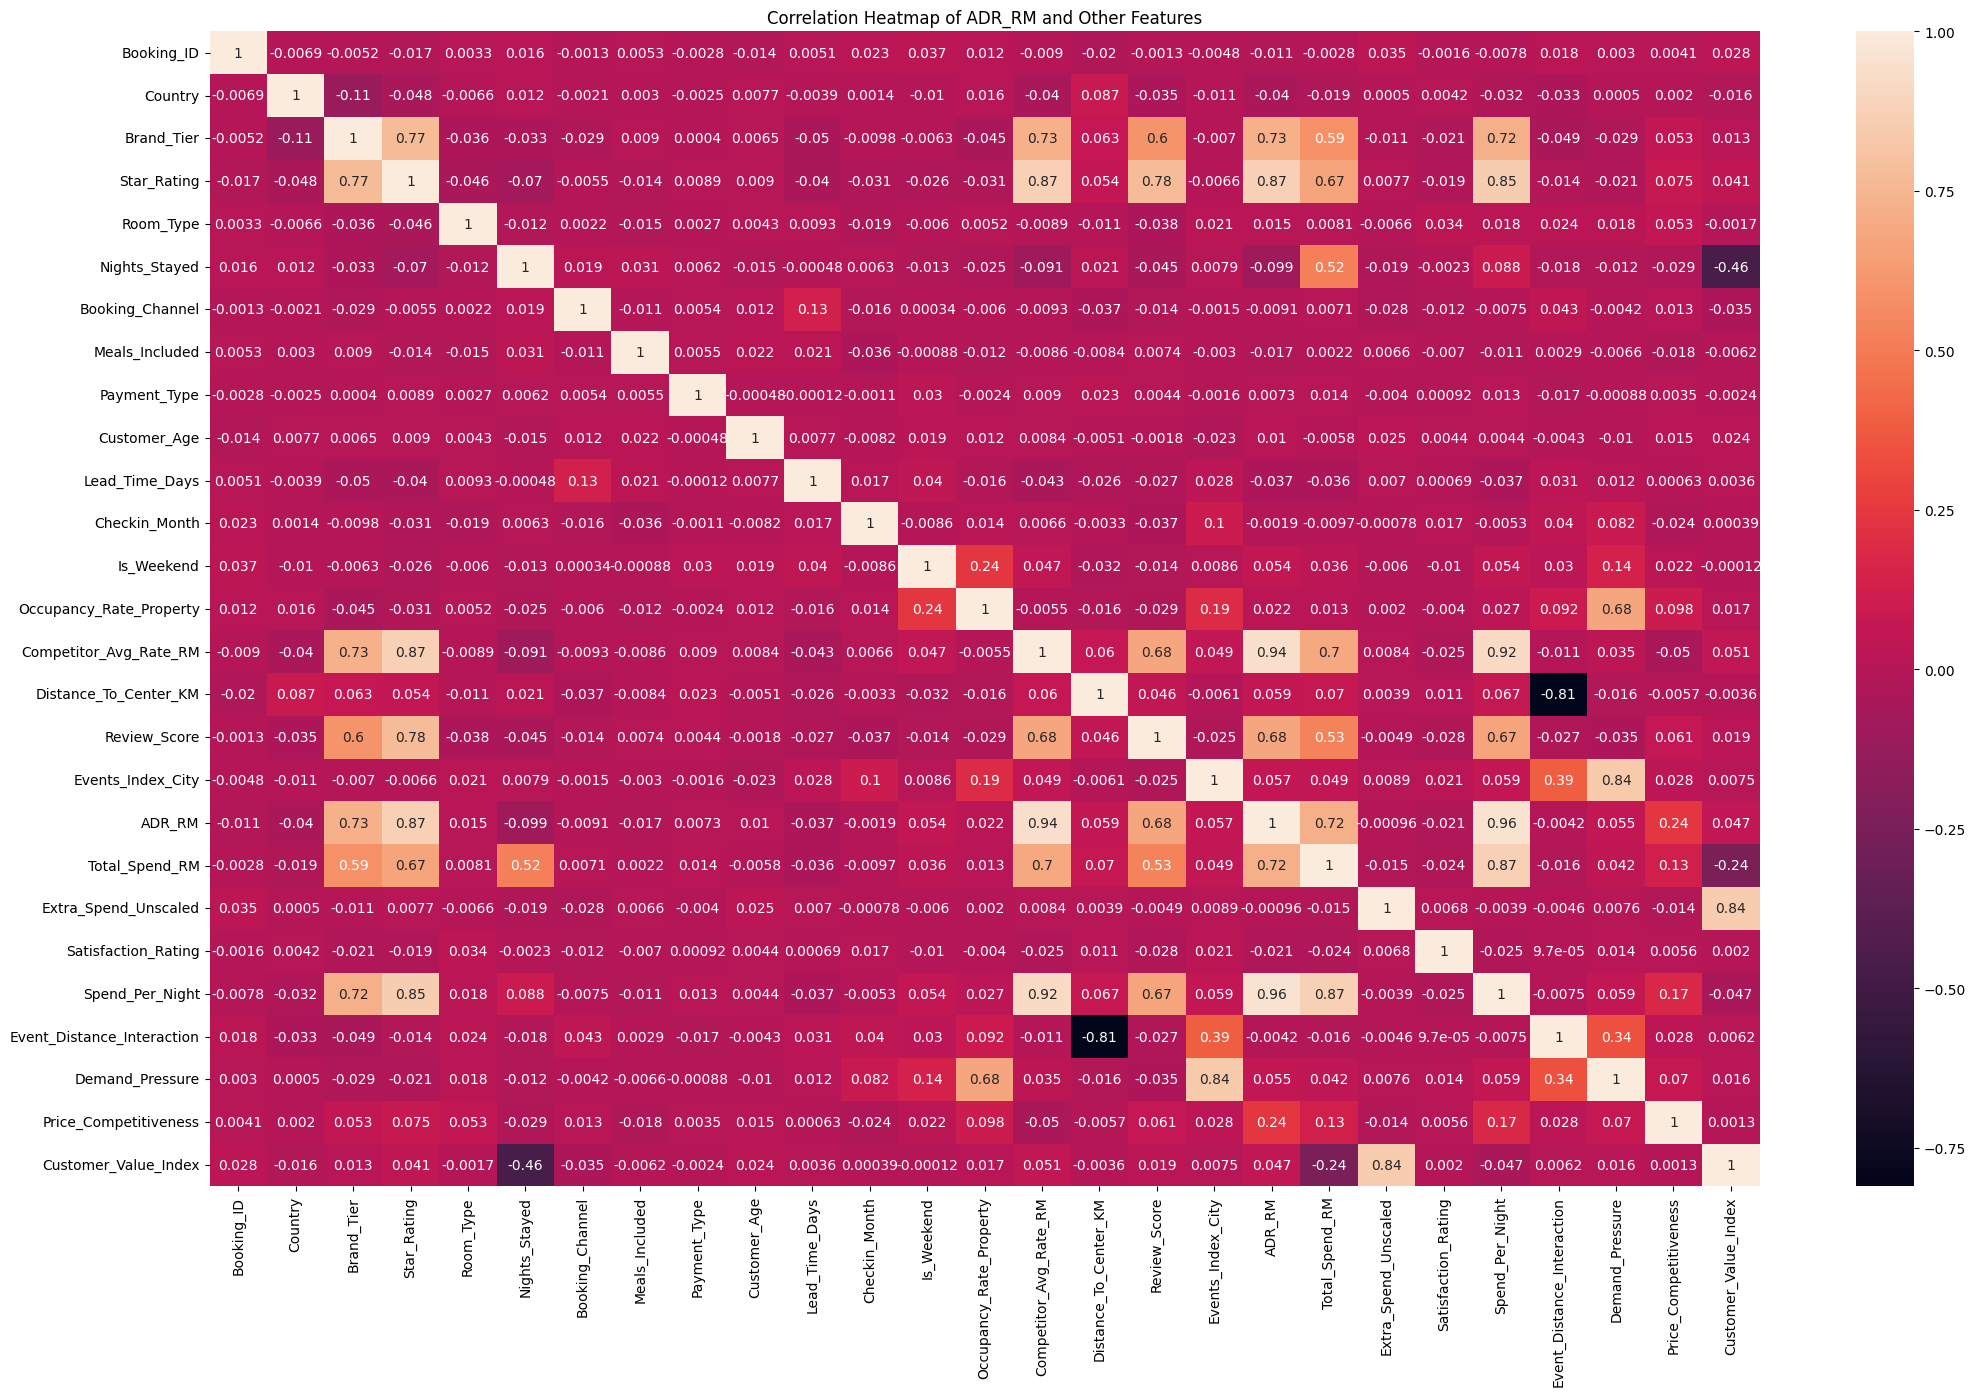

In [ ]:
plt.figure(figsize=(25,15))
sns.heatmap(numeric_corr.corr(), annot=True)
plt.title("Correlation Heatmap of ADR_RM and Other Features")
plt.show()


/tmp/ipython-input-2452351772.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr.values, y=top_corr.index, palette="viridis")


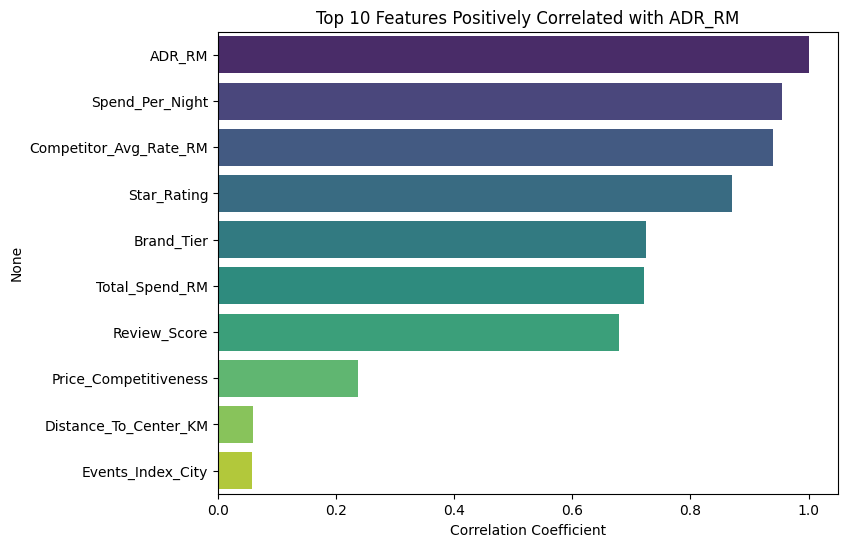

/tmp/ipython-input-2452351772.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=low_corr.values, y=low_corr.index, palette="magma")


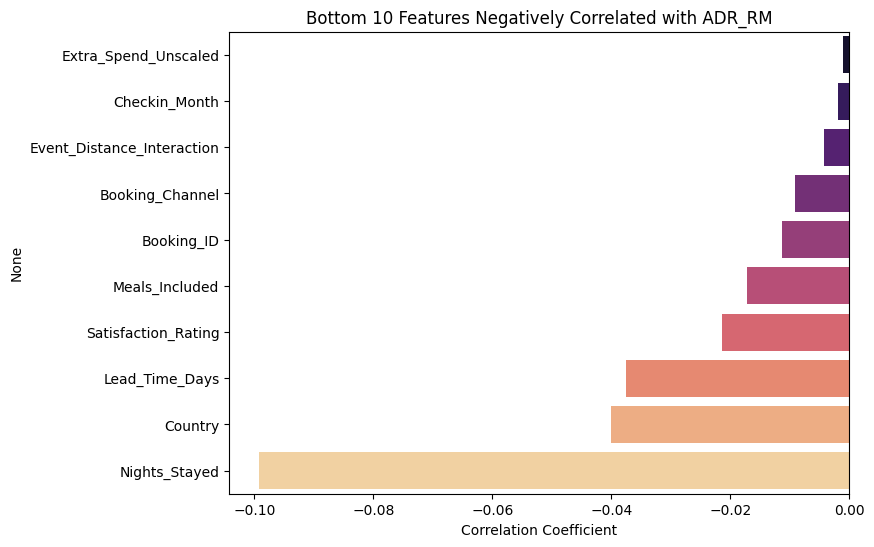

In [ ]:
top_corr = adr_corr.head(10)
low_corr = adr_corr.tail(10)

plt.figure(figsize=(8, 6))
sns.barplot(x=top_corr.values, y=top_corr.index, palette="viridis")
plt.title("Top 10 Features Positively Correlated with ADR_RM")
plt.xlabel("Correlation Coefficient")
plt.show()

plt.figure(figsize=(8, 6))
sns.barplot(x=low_corr.values, y=low_corr.index, palette="magma")
plt.title("Bottom 10 Features Negatively Correlated with ADR_RM")
plt.xlabel("Correlation Coefficient")
plt.show()


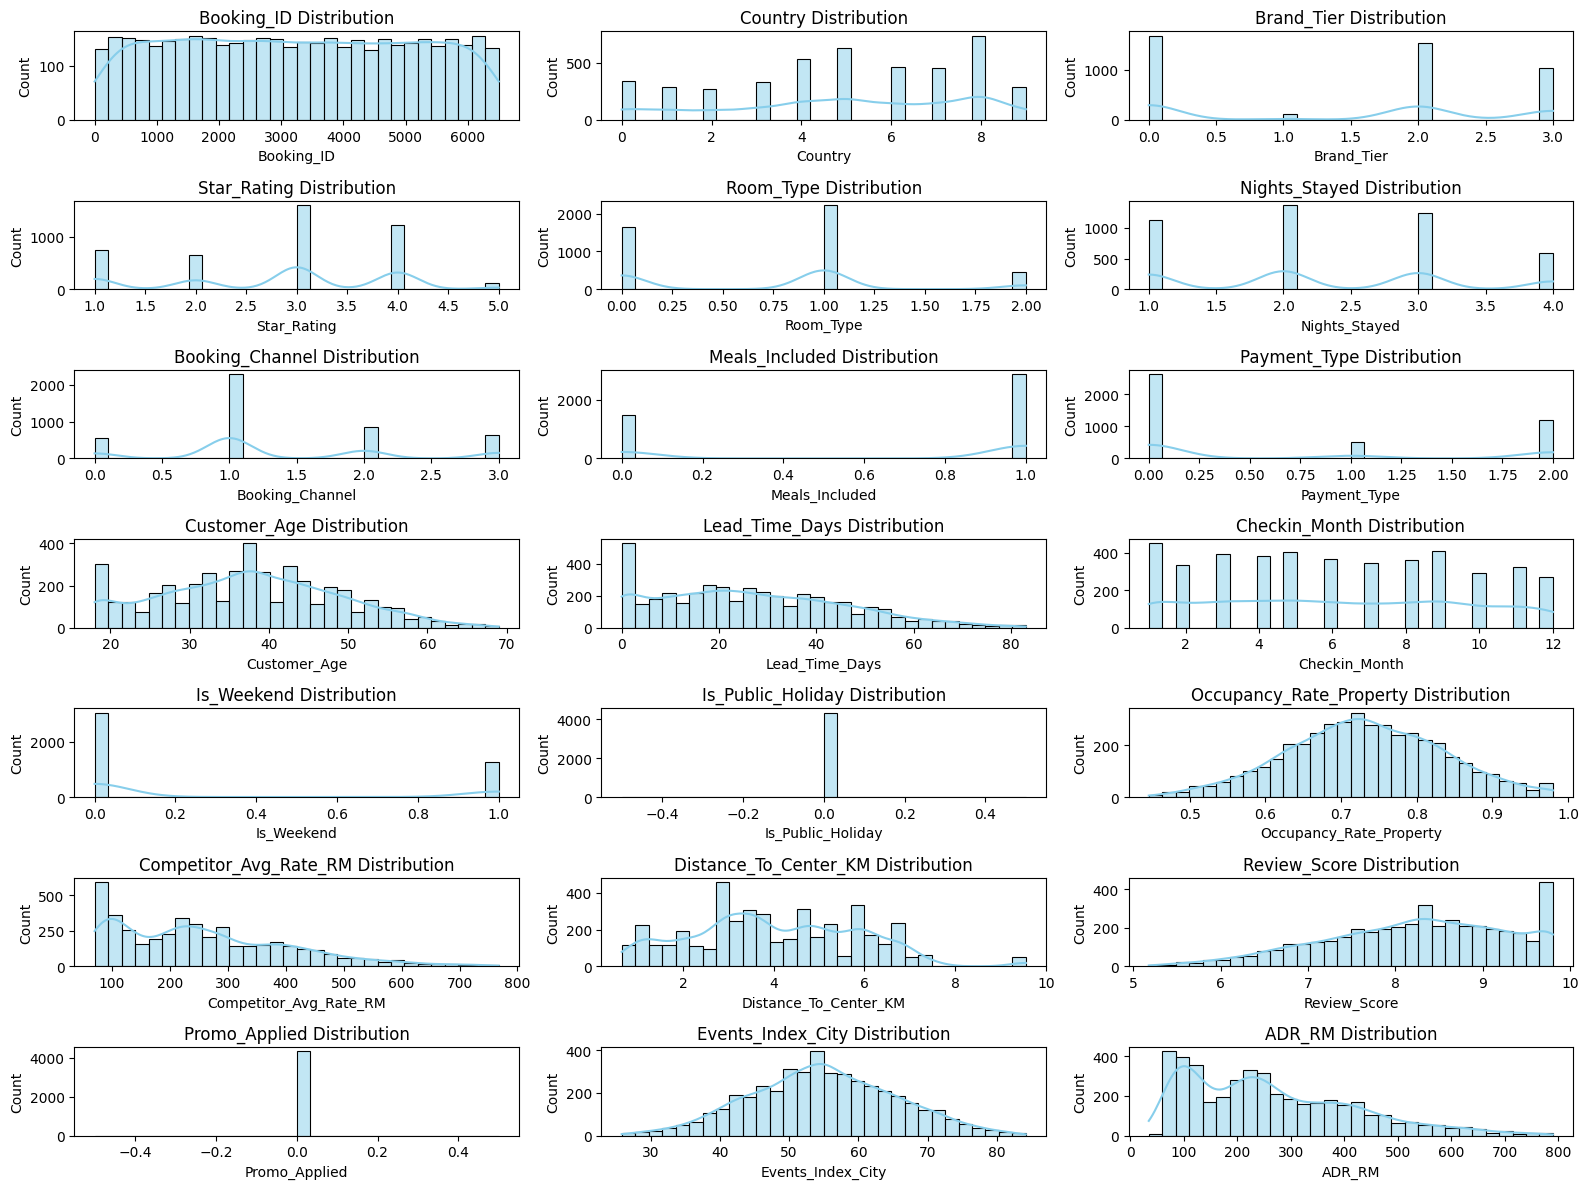

In [ ]:
# HISTOGRAMS + KDE (Distribution & Skewness)

plt.figure(figsize=(16, 12))
for i, col in enumerate(numeric_cols[:21], 1):  # show first 17 numeric
    plt.subplot(7, 3, i)
    sns.histplot(eda_df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'{col} Distribution')
plt.tight_layout()
plt.show()

/tmp/ipython-input-987114921.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Room_Type', y='ADR_RM', data=eda_df, palette='Set2')


Text(0.5, 1.0, 'ADR Distribution by Room Type')

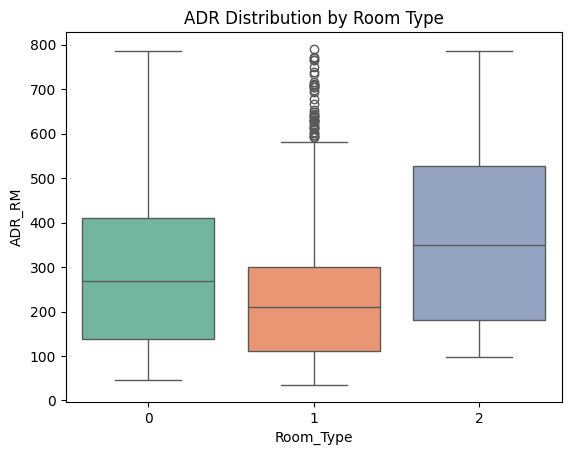

In [ ]:
# BOXPLOT ADR Distribution by Room Type

sns.boxplot(x='Room_Type', y='ADR_RM', data=eda_df, palette='Set2')
plt.title("ADR Distribution by Room Type")


/tmp/ipython-input-3103336925.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Booking_Channel', y='ADR_RM', data=eda_df, palette='Set2')


Text(0.5, 1.0, 'ADR Distribution by Booking Channel')

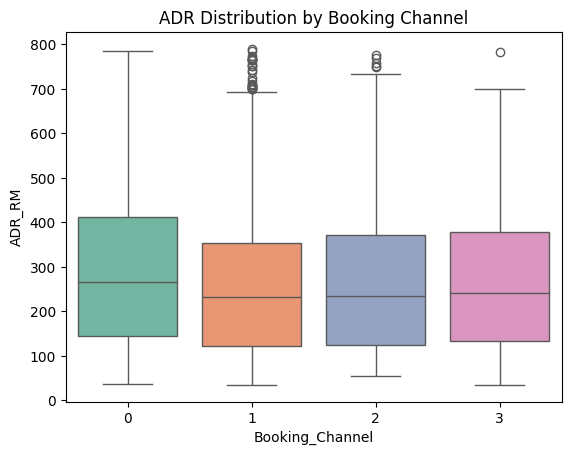

In [ ]:
# BOXPLOT ADR Distribution by Booking Channel

sns.boxplot(x='Booking_Channel', y='ADR_RM', data=eda_df, palette='Set2')
plt.title("ADR Distribution by Booking Channel")

/tmp/ipython-input-3188372730.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Meals_Included', y='ADR_RM', data=eda_df, palette='Set2')


Text(0.5, 1.0, 'ADR Distribution by Meals Included')

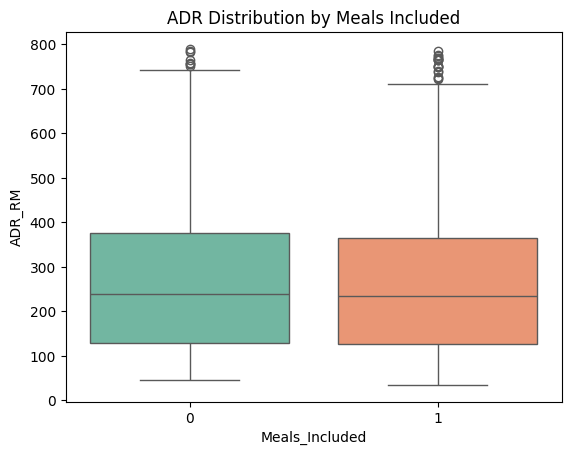

In [ ]:
# BOXPLOT ADR Distribution by Meals Included

sns.boxplot(x='Meals_Included', y='ADR_RM', data=eda_df, palette='Set2')
plt.title("ADR Distribution by Meals Included")

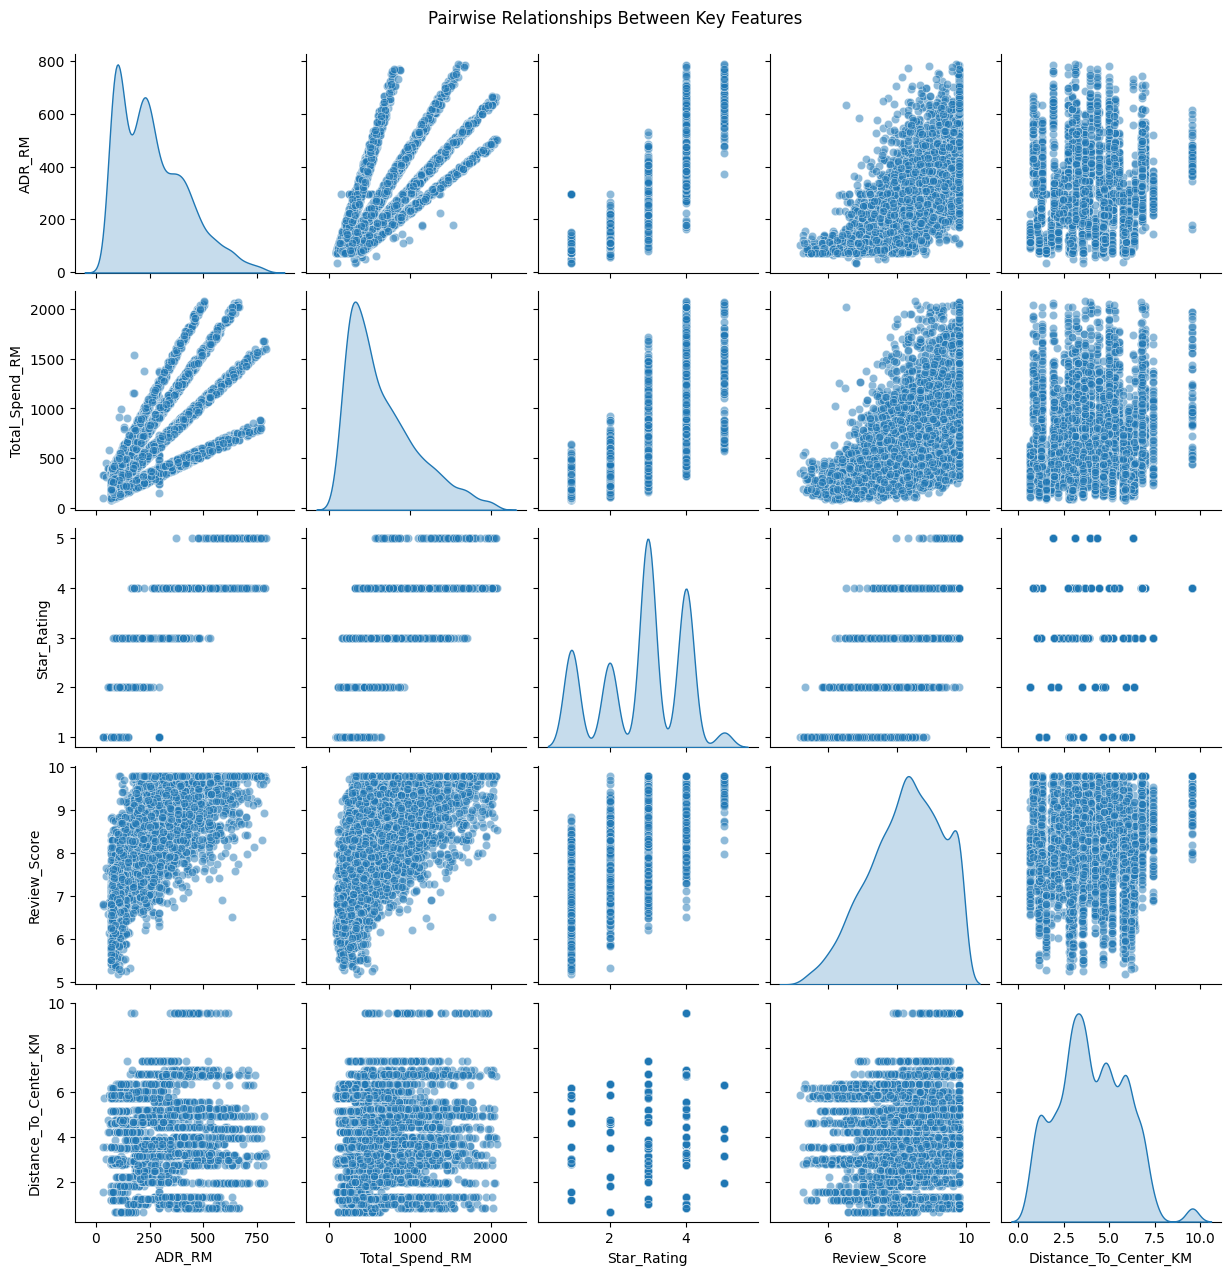

In [ ]:
# PAIRPLOT (Selected Important Variables)

selected = ['ADR_RM', 'Total_Spend_RM', 'Star_Rating',
            'Review_Score', 'Distance_To_Center_KM']
sns.pairplot(eda_df[selected], diag_kind='kde', plot_kws={'alpha':0.5})
plt.suptitle('Pairwise Relationships Between Key Features', y=1.02)
plt.show()

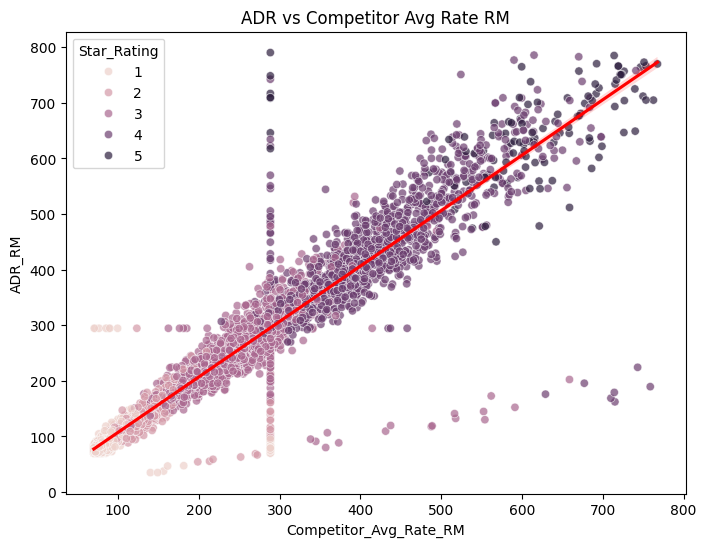

In [ ]:
# SCATTERPLOT (ADR vs Distance)

plt.figure(figsize=(8,6))
sns.scatterplot(data=eda_df, x='Competitor_Avg_Rate_RM', y='ADR_RM', hue='Star_Rating', alpha=0.7)
sns.regplot(data=eda_df, x='Competitor_Avg_Rate_RM', y='ADR_RM', scatter=False, color='red')
plt.title('ADR vs Competitor Avg Rate RM')
plt.show()


# **Regression**

**Load New Cleaned Dataset for Regression (For_Regression_cleaned_encoded_normalized.csv)**

In [ ]:
regression_df=pd.read_csv('/content/For_Regression_cleaned_encoded_normalized.csv')
regression_df.head()

,Booking_ID,Country,Brand_Tier,Star_Rating,Room_Type,Nights_Stayed,Booking_Channel,Meals_Included,Payment_Type,Customer_Age,Lead_Time_Days,Checkin_Month,Is_Weekend,Is_Public_Holiday,Occupancy_Rate_Property,Competitor_Avg_Rate_RM,Distance_To_Center_KM,Review_Score,Promo_Applied,Events_Index_City,Total_Spend_RM,Extra_Spend_Unscaled,Satisfaction_Rating,Spend_Per_Night,Event_Distance_Interaction,Demand_Pressure,Price_Competitiveness,Customer_Value_Index,ADR_RM
0,-0.395127,0.010891,-1.177065,-1.678259,-1.136013,1.696799,1.865455,-1.397241,1.516693,-1.385938,0.741407,1.714678,-0.644125,0.0,0.380958,-1.040489,-0.579580,-0.695655,0.0,0.129505,-0.543524,-0.435050,-0.181098,-1.072646,0.199734,0.286271,-0.285390,-0.800818,103.12
1,1.327549,0.385259,0.460015,0.148007,-1.136013,-0.300439,-0.402096,0.715696,-0.760581,-0.228929,2.000102,1.125619,-0.644125,0.0,1.327015,-0.313986,1.517069,1.073120,0.0,-0.837576,-0.314238,0.310361,1.171203,-0.205708,-1.056589,-0.038095,0.376154,0.245416,234.31
2,-1.267680,0.759627,-1.177065,-1.678259,0.427900,0.698180,-0.402096,0.715696,1.516693,0.127073,-0.674624,1.714678,1.552494,0.0,0.244414,-1.192030,-0.639329,-0.849462,0.0,-0.164412,-0.737660,-0.187445,-0.181098,-1.061732,0.139705,-0.013465,-0.116139,-0.488697,83.98
3,-0.729944,-0.737844,-1.177065,-1.678259,-1.136013,1.696799,0.731679,0.715696,-0.760581,-0.317930,-0.307505,1.714678,-0.644125,0.0,0.751578,0.202263,0.995622,-2.137591,0.0,1.087104,-0.444269,0.973560,-0.181098,-0.991852,-0.486275,1.272066,-3.720163,-0.098544,94.18
4,1.581198,0.385259,0.460015,0.148007,0.427900,-0.300439,-0.402096,0.715696,-0.760581,-0.228929,-0.517287,1.420148,-0.644125,0.0,0.127376,-0.310873,-0.291698,0.073377,0.0,-0.505735,-0.375838,-1.057928,1.171203,-0.289280,-0.278956,-0.330937,-0.659580,-0.891188,193.02


**FEATURES list & the TARGET**

In [ ]:
FEATURES = [
    "Spend_Per_Night","Competitor_Avg_Rate_RM","Star_Rating","Brand_Tier","Total_Spend_RM",
    "Review_Score","Customer_Value_Index","Occupancy_Rate_Property", "Price_Competitiveness","Distance_To_Center_KM","Country",
    "Nights_Stayed","Meals_Included","Satisfaction_Rating","Customer_Age","Payment_Type",
    "Demand_Pressure","Event_Distance_Interaction"
]

TARGET = "ADR_RM"

X = regression_df[FEATURES].copy()
y = regression_df[TARGET].astype(float)

**Train/Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=42)

## **Simple Linear Regressor**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error
from pprint import pprint


model_linear=LinearRegression()

#Training

model_linear.fit(X_train, y_train)

#Predicting

y_pred=model_linear.predict(X_test)

#Evaluation

baseline_linear= {
    'Model': "Simple Linear Regressor",
    'The R2 is': r2_score(y_test, y_pred),
    'The MSE is': mean_squared_error(y_test, y_pred),
    'The MAE is': mean_absolute_error(y_test, y_pred),
    'The RMSE is': root_mean_squared_error(y_test, y_pred),}


print("Baseline metrics:", baseline_linear)

r2 = r2_score(y_test, y_pred)
r2_rounded = round(r2, 2)
r2_percentage = r2_rounded * 100

print(f'R2 Score (rounded to 2 decimal places and as percentage): {r2_percentage:.2f}%')


Baseline metrics: {'Model': 'Simple Linear Regressor', 'The R2 is': 0.9829402537846793, 'The MSE is': 418.7274395120729, 'The MAE is': 11.69346166976173, 'The RMSE is': 20.462830681801403}
R2 Score (rounded to 2 decimal places and as percentage): 98.00%


## **Decision Tree Regressor**

In [ ]:
from sklearn.tree import DecisionTreeRegressor

model_DTR=DecisionTreeRegressor()

#Training

model_DTR.fit(X_train, y_train)

#Predicting

y_pred=model_DTR.predict(X_test)

#Evaluation

baseline_DTR= {
    'Model': "Decision Tree Regressor",
    'The R2 is': r2_score(y_test, y_pred),
    'The MSE is': mean_squared_error(y_test, y_pred),
    'The MAE is': mean_absolute_error(y_test, y_pred),
    'The RMSE is': root_mean_squared_error(y_test, y_pred),}


print("Baseline metrics:", baseline_DTR)

r2 = r2_score(y_test, y_pred)
r2_rounded = round(r2, 2)
r2_percentage = r2_rounded * 100

print(f'R2 Score (rounded to 2 decimal places and as percentage): {r2_percentage:.2f}%')


Baseline metrics: {'Model': 'Decision Tree Regressor', 'The R2 is': 0.9922787486842499, 'The MSE is': 189.51628895685155, 'The MAE is': 7.649262101085742, 'The RMSE is': 13.76649152677804}
R2 Score (rounded to 2 decimal places and as percentage): 99.00%


## **Random Forest Regressor**

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model_RFR=RandomForestRegressor()

#Training

model_RFR.fit(X_train, y_train)

#Predicting

y_pred=model_RFR.predict(X_test)

#Evaluation

baseline_RFR= {
    'Model': "Random Forest Regressor",
    'The R2 is': r2_score(y_test, y_pred),
    'The MSE is': mean_squared_error(y_test, y_pred),
    'The MAE is': mean_absolute_error(y_test, y_pred),
    'The RMSE is': root_mean_squared_error(y_test, y_pred),}


print("Baseline metrics:", baseline_RFR)


r2 = r2_score(y_test, y_pred)
r2_rounded = round(r2, 2)
r2_percentage = r2_rounded * 100

print(f'R2 Score (rounded to 2 decimal places and as percentage): {r2_percentage:.2f}%')


Baseline metrics: {'Model': 'Random Forest Regressor', 'The R2 is': 0.996443774818146, 'The MSE is': 87.28670672655069, 'The MAE is': 4.375290018563115, 'The RMSE is': 9.342735505543903}
R2 Score (rounded to 2 decimal places and as percentage): 100.00%


In [ ]:
comp_table = pd.DataFrame([baseline_linear, baseline_DTR, baseline_RFR])
display(comp_table)

,Model,The R2 is,The MSE is,The MAE is,The RMSE is
0,Simple Linear Regressor,0.982940,418.727440,11.693462,20.462831
1,Decision Tree Regressor,0.992279,189.516289,7.649262,13.766492
2,Random Forest Regressor,0.996444,87.286707,4.375290,9.342736


## **Tuned Models**

### **Tuning of Random Forest Regressor (using 5-fold cross-validation)**

In [ ]:
# Tuning & 5-fold CV for the primary regressor (RandomForest)

from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import randint, uniform




In [ ]:
# RandomizedSearchCV over key hyperparameters

param_dist = {
    "n_estimators": randint(200, 700),       # number of trees
    "max_depth": randint(5, 30),             # tree depth
    "min_samples_split": randint(2, 12),     # min samples to split a node
    "min_samples_leaf": randint(1, 8),       # min samples at a leaf
    "max_features": ["sqrt", "log2", 0.5, 0.8],  # features per split
}
cv = KFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=15,                            # increase to 50/80 if we have more time/compute
    scoring="r2",                         # higher is better
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

search.fit(X_train, y_train)

best_rf = search.best_estimator_
best_params = search.best_params_
best_cv_r2 = search.best_score_

print("\nBest params from CV:", best_params)
print("Best 5-fold CV R2:", round(best_cv_r2))

Fitting 5 folds for each of 15 candidates, totalling 75 fits

Best params from CV: {'max_depth': 27, 'max_features': 0.8, 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 684}
Best 5-fold CV R2: 1


In [ ]:
# Evaluate tuned model on the held-out test set

y_pred_best = best_rf.predict(X_test)

tuned_RFR = {
    "Model": "Random Forest (Tuned, CV=5)",
    "The RMSE is": root_mean_squared_error(y_test, y_pred_best),
    "The MAE is": mean_absolute_error(y_test, y_pred_best),
    'The MSE is': mean_squared_error(y_test, y_pred_best),
    "The R2 is": r2_score(y_test, y_pred_best),
}

In [ ]:
# Compare "before vs after" in a neat table

metric_table = pd.DataFrame([baseline_RFR, tuned_RFR])
display(metric_table)


,Model,The R2 is,The MSE is,The MAE is,The RMSE is
0,Random Forest Regressor,0.996444,87.286707,4.37529,9.342736
1,"Random Forest (Tuned, CV=5)",0.996243,92.219671,4.70397,9.603107


### **Tuning of Decision Tree Regressor (using 5-fold cross-validation)**

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, KFold
from scipy.stats import randint

cv = KFold(n_splits=5, shuffle=True, random_state=42)

param_dist = {
    "criterion": ["squared_error", "friedman_mse", "absolute_error"],
    "splitter": ["best"],
    "max_depth":  randint(5, 30),
    "min_samples_split": randint(2, 12),
    "min_samples_leaf": randint(1, 8),
    "max_features": ["sqrt", "log2", 0.5, 0.8]
}

rand_search = RandomizedSearchCV(
    estimator=model_DTR,
    param_distributions=param_dist,
    n_iter=120,                 # Use 40–120 depending on time budget
    scoring="r2",               # higher is better
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rand_search.fit(X_train, y_train)
best_dt = rand_search.best_estimator_
print("Best params:", rand_search.best_params_)
print("Best 5-fold CV R2:", round(rand_search.best_score_, 4))


Fitting 5 folds for each of 120 candidates, totalling 600 fits
Best params: {'criterion': 'absolute_error', 'max_depth': 19, 'max_features': 0.8, 'min_samples_leaf': 2, 'min_samples_split': 3, 'splitter': 'best'}
Best 5-fold CV R2: 0.9859


In [ ]:
# Evaluate tuned model on the held-out test set

y_pred_best = best_dt.predict(X_test)

tuned_DTR = {
    "Model": "Decision Tree (Tuned, CV=5)",
    "The RMSE is": root_mean_squared_error(y_test, y_pred_best),
    "The MAE is": mean_absolute_error(y_test, y_pred_best),
    'The MSE is': mean_squared_error(y_test, y_pred_best),
    "The R2 is": r2_score(y_test, y_pred_best),
}

print("\nTuned Model Performance:")
print(tuned_DTR)

# R² as percentage
r2_rounded = round(r2, 2)
r2_percentage = r2_rounded * 100
print(f'R2 Score (rounded to 2 decimal places and as percentage): {r2_percentage:.2f}%')


Tuned Model Performance:
{'Model': 'Decision Tree (Tuned, CV=5)', 'The RMSE is': 15.913802217608293, 'The MAE is': 7.87492049454325, 'The MSE is': 253.24910102115462, 'The R2 is': 0.9896821536278746}
R2 Score (rounded to 2 decimal places and as percentage): 100.00%


In [ ]:
# Compare "before vs after" in a neat table

metric_table = pd.DataFrame([baseline_DTR, tuned_DTR])
display(metric_table)

,Model,The R2 is,The MSE is,The MAE is,The RMSE is
0,Decision Tree Regressor,0.992279,189.516289,7.649262,13.766492
1,"Decision Tree (Tuned, CV=5)",0.989682,253.249101,7.874920,15.913802


## **Final Comparison Table**

In [ ]:
import pandas as pd

# Define direction (higher = better, lower = better)
higher_better = ["The R2 is"]
lower_better = ["The MAE is", "The RMSE is", "The MSE is"]

# Example DataFrame (replace this with your actual metric_table)
final_table = pd.DataFrame([baseline_linear, baseline_DTR, baseline_RFR, tuned_RFR, tuned_DTR ])

# Apply gradient color styling
final_styled_table = (
    final_table.style
    .background_gradient(cmap="Greens", subset=["The R2 is"])     # darker = higher
    .background_gradient(cmap="Reds_r", subset=["The MAE is", "The RMSE is", "The MSE is" ])  # darker = better
    .set_properties(**{
        "text-align": "center",
        "font-size": "14px",
        "font-weight": "500",
        "border-color": "#ddd",
        "border-width": "1px",
        "border-style": "solid",
        "padding": "6px"
    })
    .set_table_styles([
        {"selector": "thead th",
         "props": [("background-color", "#f9fafb"),
                   ("color", "#111827"),
                   ("font-size", "15px"),
                   ("font-weight", "bold"),
                   ("text-align", "center"),
                   ("border-bottom", "2px solid #e5e7eb")]},
        {"selector": "caption",
         "props": [("caption-side", "bottom"),
                   ("text-align", "center"),
                   ("font-size", "13px"),
                   ("color", "#6b7280"),
                   ("padding-top", "4px")]}
    ])
    .set_caption("Model Performance Comparison — Darker Green = Higher R²")
)

final_styled_table


,Model,The R2 is,The MSE is,The MAE is,The RMSE is
0,Simple Linear Regressor,0.982940,418.727440,11.693462,20.462831
1,Decision Tree Regressor,0.992279,189.516289,7.649262,13.766492
2,Random Forest Regressor,0.996444,87.286707,4.375290,9.342736
3,"Random Forest (Tuned, CV=5)",0.996243,92.219671,4.703970,9.603107
4,"Decision Tree (Tuned, CV=5)",0.989682,253.249101,7.874920,15.913802
